<a href="https://colab.research.google.com/github/sreejas7919-bit/DSA_6/blob/main/CASESTUDY_CUST_CHURN_PREDICT_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CASE STUDY : CUSTOMER CHURN PREDICTION MACHINE LEARNING PROJECT

In [103]:
#Training data Load
import pandas as pd

train = pd.read_csv("/content/Training_data.csv")
train.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [104]:
#Data Explore (EDA)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [105]:
train.shape

(5634, 21)

In [106]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [107]:
train.isnull().sum()
# Missing values

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [108]:
train['Churn'].value_counts()
# Target distribution

,count
Churn,
No,4130
Yes,1504


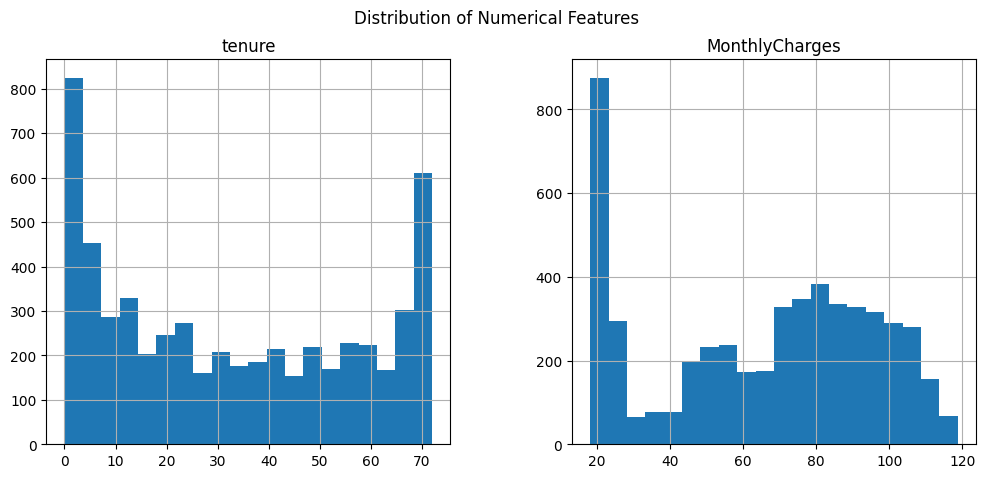

In [109]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]

train[num_cols].hist(figsize=(12,5),bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.show()

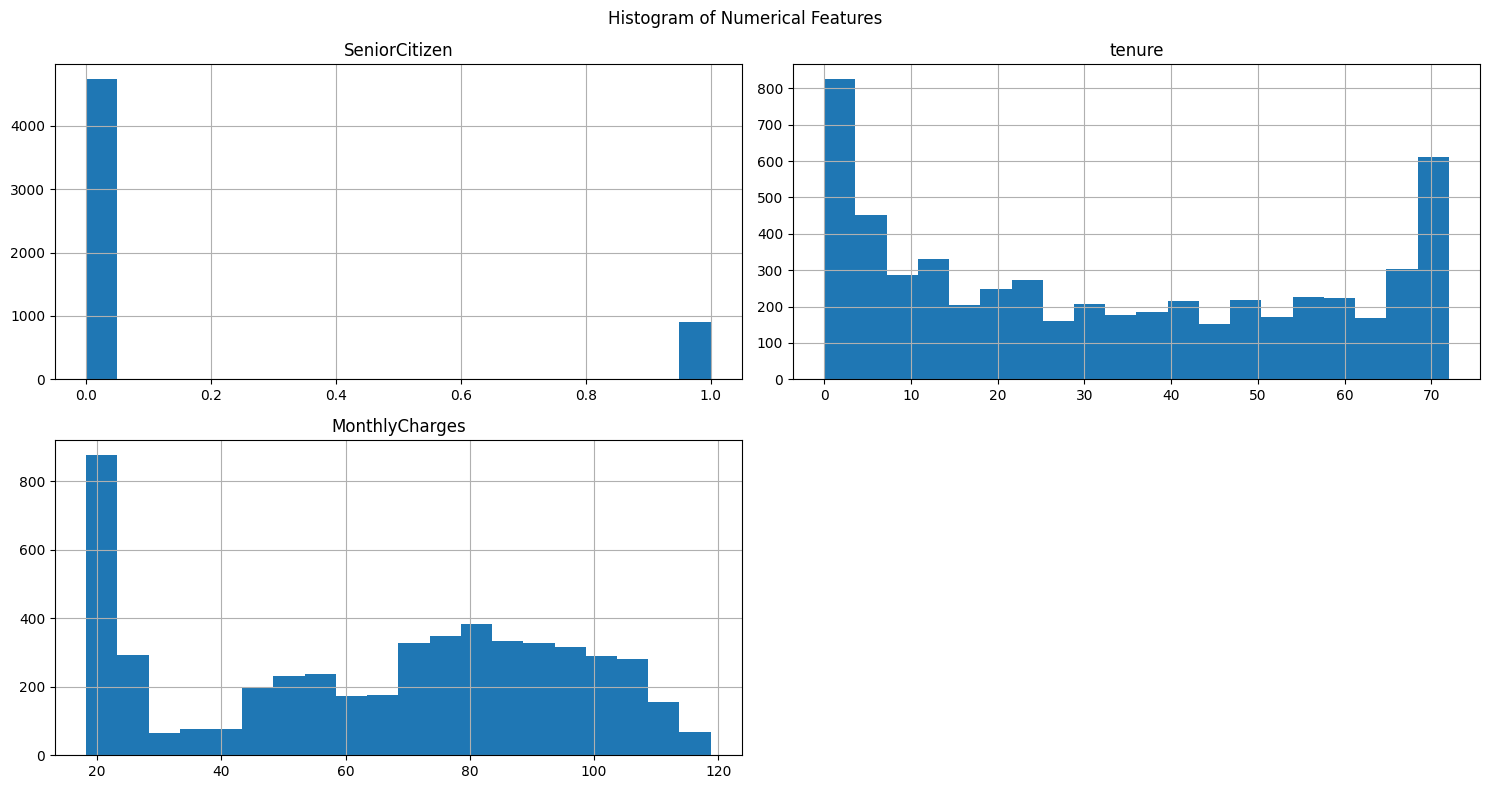

In [110]:
train.select_dtypes(include=['int64','float64']).hist(figsize=(15,8), bins=20)

plt.suptitle("Histogram of Numerical Features")
plt.tight_layout()
plt.show()

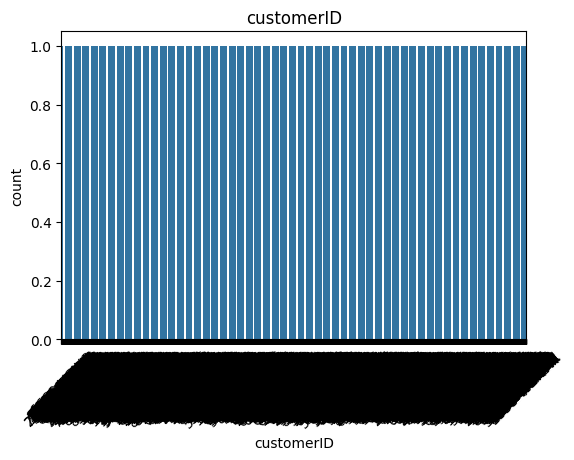

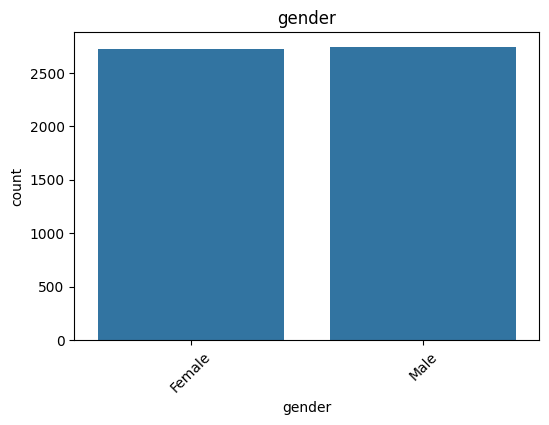

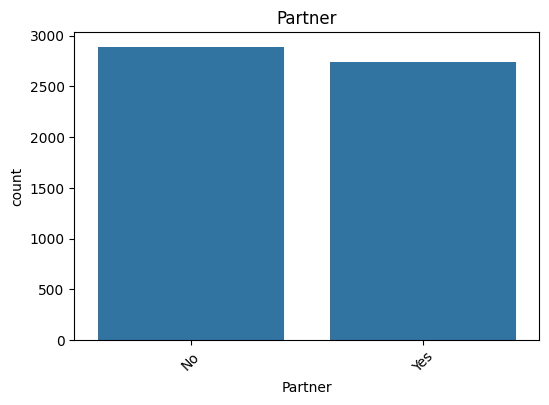

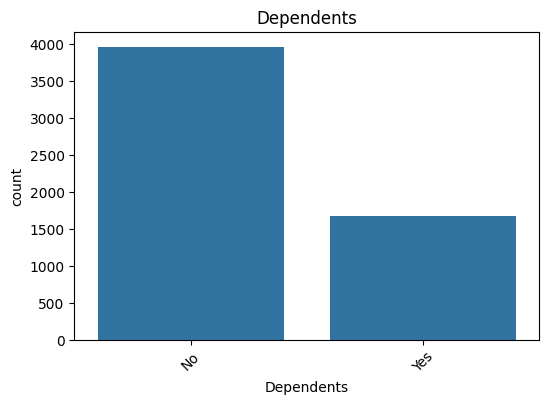

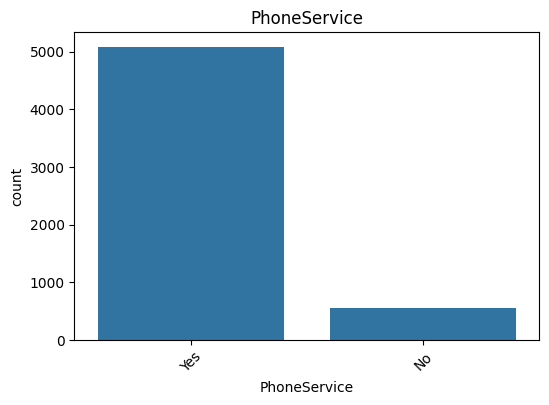

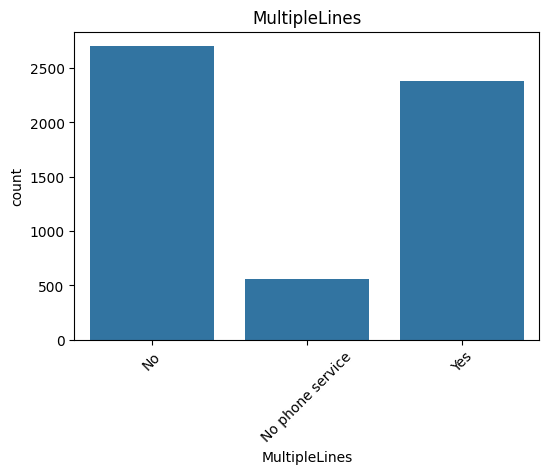

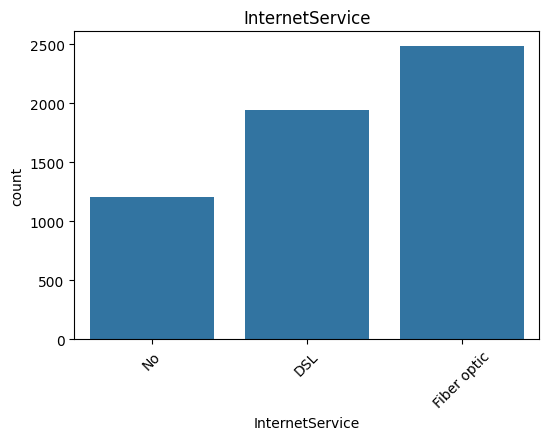

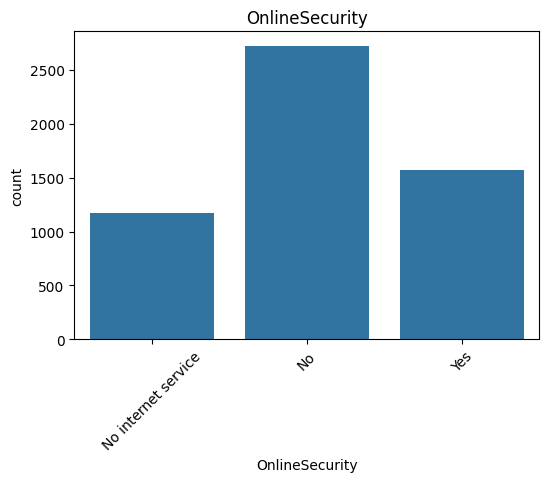

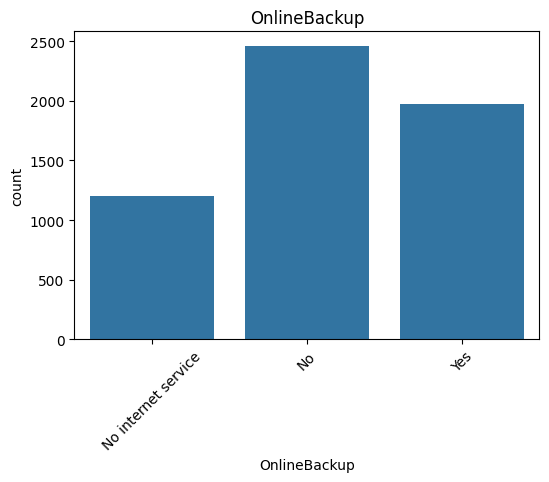

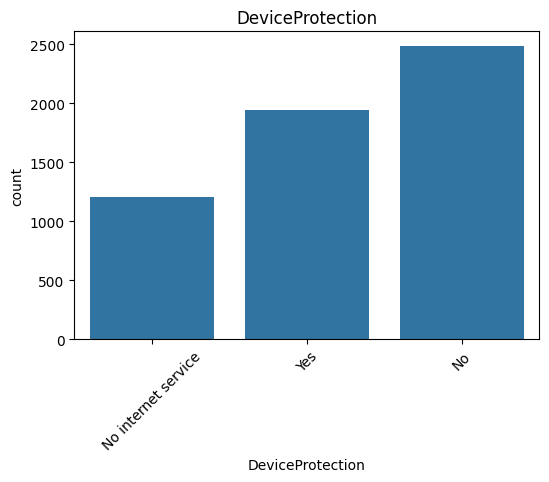

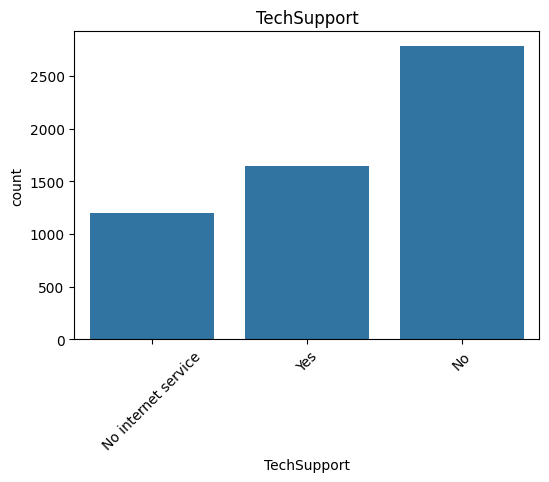

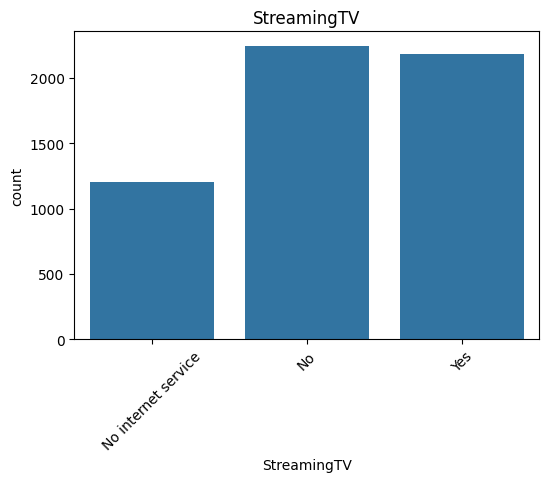

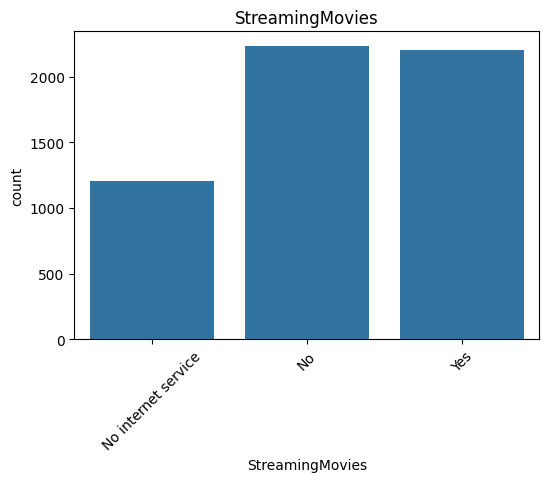

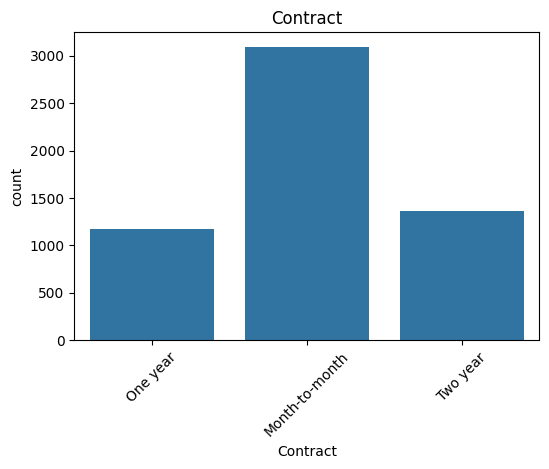

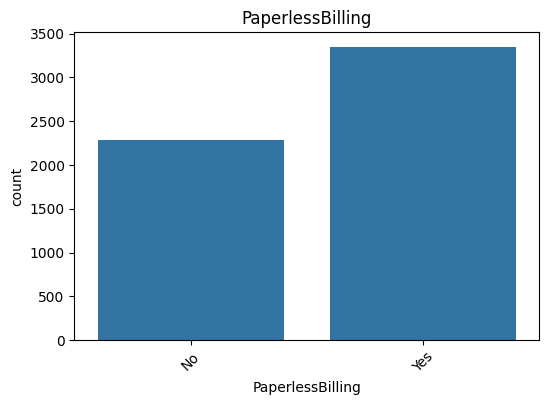

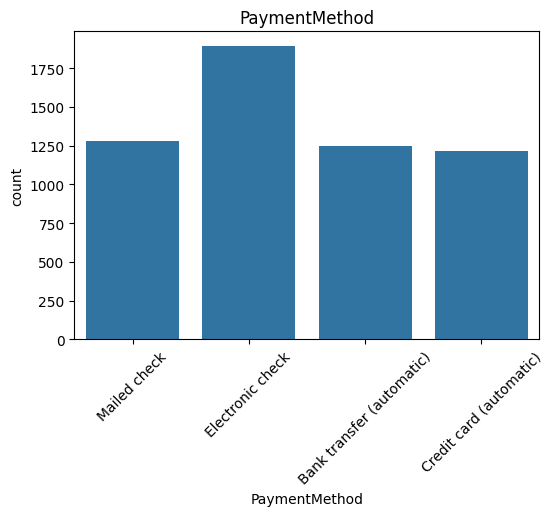

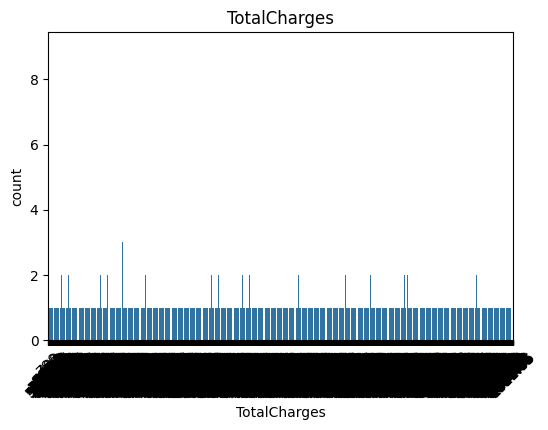

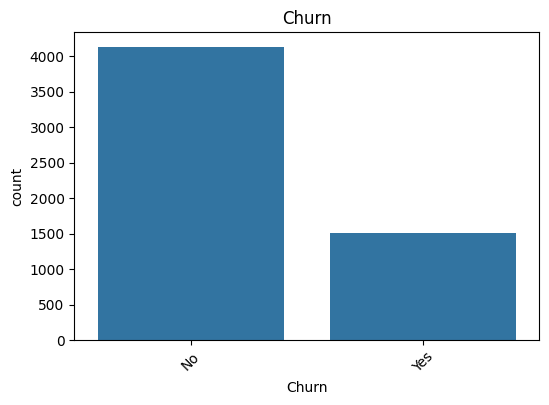

In [111]:
#Categorical Feature Distribution
import seaborn as sns
import matplotlib.pyplot as plt

categorical_columns = train.select_dtypes(include="object").columns

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=train[col])
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

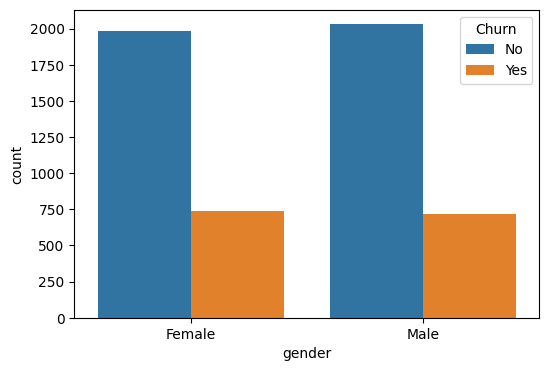

In [112]:
#Relationship between Features and Churn
#Gender vs Churn

plt.figure(figsize=(6,4))
sns.countplot(x="gender",hue="Churn",data=train)
plt.show()

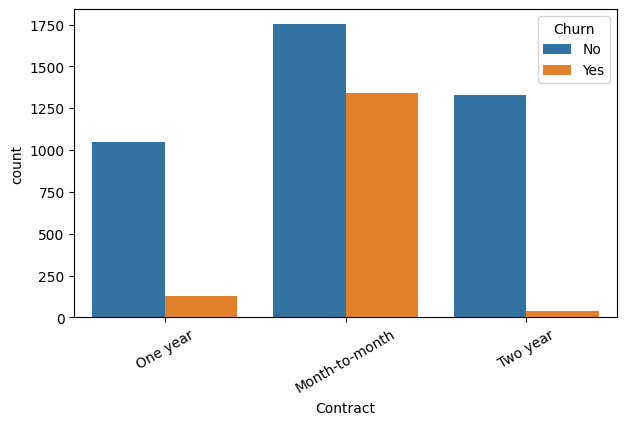

In [113]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract",hue="Churn",data=train)
plt.xticks(rotation=30)
plt.show()

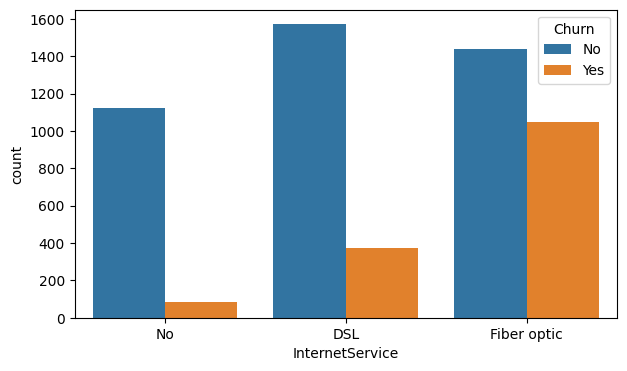

In [114]:
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService",hue="Churn",data=train)
plt.show()

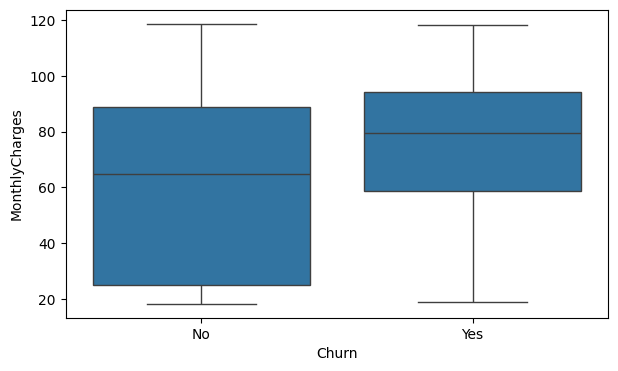

In [115]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn",y="MonthlyCharges",data=train)
plt.show()

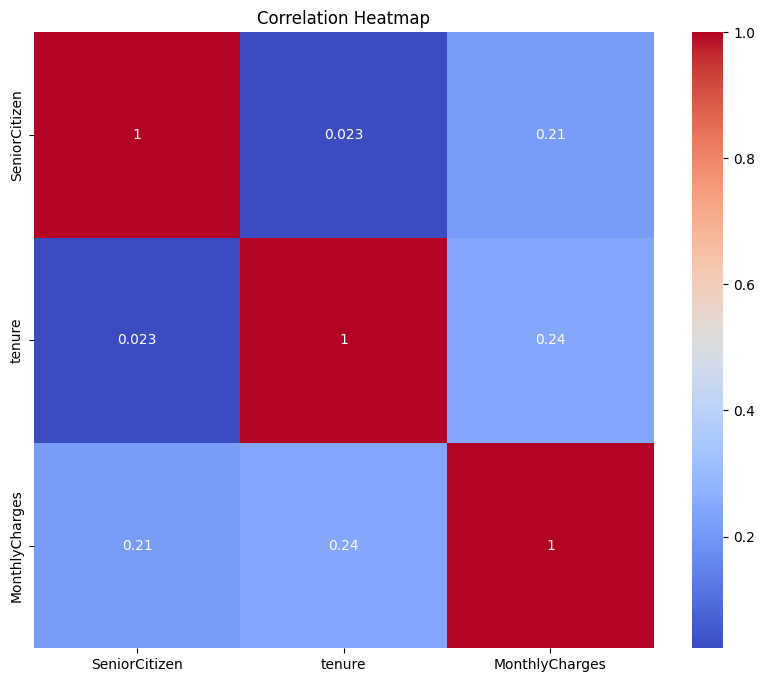

In [116]:
plt.figure(figsize=(10,8))

sns.heatmap(train.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [117]:
#duplicate values
train.duplicated().sum()


np.int64(0)

In [119]:
#handle missing value
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [142]:
#SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = ["tenure","MonthlyCharges","TotalCharges"]

# Ensure scaler fits on the X data that has correct numerical columns
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [121]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaymentMethod_Mailed check,CustomerLifetimeValue,Tenure_Contract_One year,Tenure_Contract_Two year,Tenure_Tenure_Contract_One year,Tenure_Tenure_Contract_Two year,Tenure_Tenure_Tenure_Contract_One year,Tenure_Tenure_Tenure_Contract_Two year,Tenure_Tenure_Tenure_Tenure_Contract_One year,Tenure_Tenure_Tenure_Tenure_Contract_Two year
0,0,0.097232,-1.551236,-0.693914,0,0,0,1,0,0,...,1,-0.150830,0.097232,0.000000,0.009454,0.00000,0.000919,0.000000,0.000089,0.000000
1,0,-0.187173,-1.034282,-0.576140,0,0,0,0,1,0,...,1,0.193590,-0.000000,-0.000000,0.000000,0.00000,-0.000000,-0.000000,0.000000,0.000000
2,0,0.950447,1.136927,1.508610,1,0,0,1,0,1,...,0,1.080588,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
3,0,0.259749,-1.551236,-0.653302,1,1,0,1,0,0,...,0,-0.402932,0.000000,0.259749,0.000000,0.06747,0.000000,0.017525,0.000000,0.004552
4,0,0.422266,-0.482864,-0.039159,0,1,1,0,1,0,...,0,-0.203897,0.422266,0.000000,0.178309,0.00000,0.075294,0.000000,0.031794,0.000000


In [143]:
#Feature Engineering

#Customer Lifetime Value
# This must run after numerical columns are scaled (if scaling is part of feature creation basis)
X["CustomerLifetimeValue"] = X["tenure"] * X["MonthlyCharges"]

In [181]:
#Separate Features and Target
from sklearn.preprocessing import LabelEncoder

X = train.drop("Churn", axis=1)
y = train["Churn"]

# Encode the target variable 'y' to numerical (0 and 1)
le = LabelEncoder()
y = le.fit_transform(y)


In [144]:
#Tenure × Contract
# Use base_contract_columns defined after one-hot encoding
for col in base_contract_columns:
    X["Tenure_"+col] = X["tenure"] * X[col]
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue,Tenure_Contract_One year,Tenure_Contract_Two year
0,0,0.097232,-1.541793,-0.693923,0,0,0,1,0,0,...,0,1,0,0,0,0,1,-0.149911,0.097232,0.000000
1,0,-0.187173,-1.024876,-0.576171,0,0,0,0,1,0,...,0,0,0,1,0,0,1,0.191829,-0.000000,-0.000000
2,0,0.950447,1.141008,1.508417,1,0,0,1,0,1,...,1,0,0,0,0,1,0,1.084467,0.000000,0.000000
3,0,0.259749,-1.552131,-0.653514,1,1,0,1,0,0,...,0,0,1,1,0,0,0,-0.403165,0.000000,0.259749
4,0,0.422266,-0.490728,-0.039101,0,1,1,0,1,0,...,0,1,0,1,0,0,0,-0.207218,0.422266,0.000000


In [165]:
X_train.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [166]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [167]:
cat_cols = X.select_dtypes(include="object").columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [168]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [171]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train);

In [172]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [173]:
y_pred = lr.predict(X_valid)

In [174]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.80301685891748


In [175]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)
print(cm)

[[733  93]
 [129 172]]


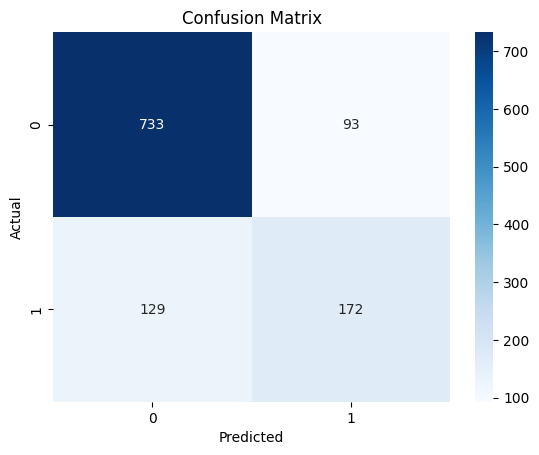

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [177]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87       826
         Yes       0.65      0.57      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



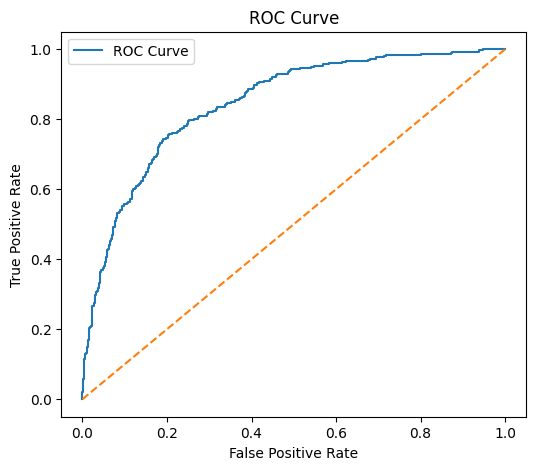

ROC-AUC Score: 0.845068496456525


In [183]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(X_valid)[:, 1]

fpr, tpr, _ = roc_curve(y_valid, y_prob, pos_label="Yes")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))

In [184]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_valid)

print("Decision Tree Accuracy:", accuracy_score(y_valid, dt_pred))

Decision Tree Accuracy: 0.7444543034605147


In [185]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)

print("Random Forest Accuracy:", accuracy_score(y_valid, rf_pred))

Random Forest Accuracy: 0.8065661047027507


In [186]:
print("Logistic Regression:", accuracy_score(y_valid, y_pred))
print("Decision Tree:", accuracy_score(y_valid, dt_pred))
print("Random Forest:", accuracy_score(y_valid, rf_pred))

Logistic Regression: 0.80301685891748
Decision Tree: 0.7444543034605147
Random Forest: 0.8065661047027507


In [187]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Score: 0.7969811812940044


In [ ]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_valid)

print("Best Model Accuracy:", accuracy_score(y_valid, best_pred))

In [188]:
test = pd.read_csv("Testing_data.csv")

In [190]:
customer_id = test["customerID"]

In [192]:
test = test.drop("customerID", axis=1)

In [198]:
test["TotalCharges"] = pd.to_numeric(test["TotalCharges"], errors="coerce")
test["TotalCharges"].fillna(train["TotalCharges"].median(), inplace=True)

mode_gender = train["gender"].mode()[0]
mode_online_security = train["OnlineSecurity"].mode()[0]
median_monthly_charges = train["MonthlyCharges"].median()

test["gender"].fillna(mode_gender, inplace=True)
test["OnlineSecurity"].fillna(mode_online_security, inplace=True)
test["MonthlyCharges"].fillna(median_monthly_charges, inplace=True)

/tmp/ipykernel_706/3684281960.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["TotalCharges"].fillna(train["TotalCharges"].median(), inplace=True)
/tmp/ipykernel_706/3684281960.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

In [201]:
cat_cols = test.select_dtypes(include="object").columns

test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

In [202]:
# Reindex test columns to exactly match the training data columns
test = test.reindex(columns=X_train.columns, fill_value=0)

In [203]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

test[num_cols] = scaler.transform(test[num_cols])

In [204]:
prediction = best_model.predict(test)

In [205]:
prediction = pd.Series(prediction).map({0: "No", 1: "Yes"})

In [206]:
submission = pd.DataFrame({
    "CustomerID": customer_id,
    "Churn": prediction
})

submission.to_csv("submission.csv", index=False)

submission.head()

,CustomerID,Churn
0,6080-TCMYC,No
1,7285-KLOTR,No
2,7486-KSRVI,No
3,9924-JPRMC,No
4,4439-YRNVD,No


In [207]:
submission.to_csv("submission.csv", index=False)

In [208]:
submission.shape

(1409, 2)

In [209]:
submission.head()

,CustomerID,Churn
0,6080-TCMYC,No
1,7285-KLOTR,No
2,7486-KSRVI,No
3,9924-JPRMC,No
4,4439-YRNVD,No


The dataset was preprocessed, multiple machine learning models were trained and evaluated, and the best-performing model was selected using hyperparameter tuning. The final model was applied to the testing dataset to predict customer churn, and the predictions were saved in the required submission format.